# Tutorial: Why Scaling and Normalization Matters in Classification

Many classifiers depend on distances or feature magnitudes. If one feature ranges from `0–1` and another from `0–100,000`, the larger-scale feature can dominate the model—even if it is less informative.

This tutorial compares classification performance:

1. **Without scaling**
2. With **standardization** (`StandardScaler`)
3. With **min-max normalization** (`MinMaxScaler`)

We’ll use the built-in Wine dataset, whose features have very different ranges (for example, `proline` is much larger numerically than `hue`).

---
## 1. Imports and data

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine

# Load a multi-class classification dataset
wine = load_wine()

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

print(X.head())
print("\nFeature ranges:")
print(pd.DataFrame({
    "min": X.min(),
    "max": X.max(),
    "range": X.max() - X.min()
}).round(2))


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  


You should notice that feature ranges differ substantially. For example, `proline` has values in the hundreds or thousands, while some other features are near zero.

---
## 2. Split the data

Always split before fitting a scaler. Otherwise, information from the test data can leak into training.



In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


---

## 3. Compare KNN with and without scaling

K-Nearest Neighbors (KNN) is strongly affected by scale because it classifies points based on distances.


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "No scaling": KNeighborsClassifier(n_neighbors=5),

    "StandardScaler": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ]),

    "MinMaxScaler": Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results[name] = accuracy_score(y_test, predictions)

#print(results)

results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["Accuracy"]
)

print(results_df)

                Accuracy
No scaling      0.777778
StandardScaler  0.933333
MinMaxScaler    0.977778


Your precise scores can vary slightly, but scaling should substantially improve KNN.

---

## 4. Visualize the difference


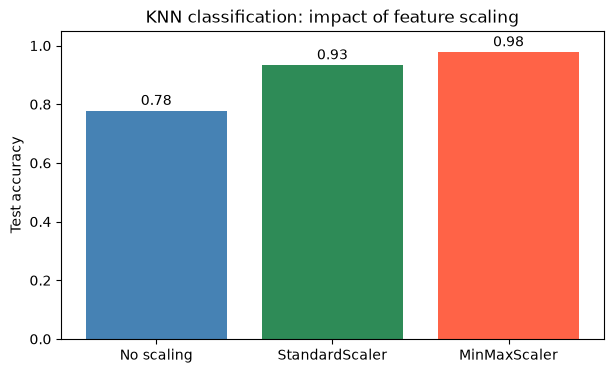

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(results_df.index, results_df["Accuracy"], color=["steelblue", "seagreen", "tomato"])
plt.ylim(0, 1.05)
plt.ylabel("Test accuracy")
plt.title("KNN classification: impact of feature scaling")

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center")

plt.show()

---

## 5. Compare an SVM too

Support Vector Machines using an RBF kernel also rely on distances, so scaling is usually essential.


In [5]:
from sklearn.svm import SVC

svm_models = {
    "SVM: no scaling": SVC(kernel="rbf", C=1.0),

    "SVM: standardized": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0))
    ]),

    "SVM: MinMax": Pipeline([
        ("scaler", MinMaxScaler()),
        ("svm", SVC(kernel="rbf", C=1.0))
    ]),
}

svm_results = {}

for name, model in svm_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    svm_results[name] = accuracy_score(y_test, predictions)

print(pd.DataFrame.from_dict(
    svm_results, orient="index", columns=["Accuracy"]
))


                   Accuracy
SVM: no scaling    0.711111
SVM: standardized  0.977778
SVM: MinMax        1.000000


---

# 6. Some concluding remarks

`StandardScaler` transforms every feature so it has approximately:

- mean = `0`
- standard deviation = `1`

`MinMaxScaler` transforms every feature so it has scaled data to the interval 0-1:

- min = `0`
- max = `1`


This means no feature dominates simply because it was measured in larger units.

---



In [6]:
std_scaler = StandardScaler()
mM_scaler = MinMaxScaler()

std_X_train = std_scaler.fit_transform(X_train)
mM_X_train  = mM_scaler.fit_transform(X_train)
std_scaled_df = pd.DataFrame(std_X_train, columns=X.columns)
mM_scaled_df = pd.DataFrame(mM_X_train, columns=X.columns)

print("========================= StandardScaler ===========================")
print(std_scaled_df.describe().loc[["mean", "std"]].round(2))
print("\n Feature ranges:")
print(pd.DataFrame({
    "min": std_scaled_df.min(),
    "max": std_scaled_df.max(),
    "range": std_scaled_df.max() - std_scaled_df.min()
}).round(2))
print("====================================================")

print("========================= MinMaxScaler ===========================")

print(mM_scaled_df.describe().loc[["mean", "std"]].round(2))
print("\n Feature ranges:")
print(pd.DataFrame({
    "min": mM_scaled_df.min(),
    "max": mM_scaled_df.max(),
    "range": mM_scaled_df.max() - mM_scaled_df.min()
}).round(2))
print("====================================================")



========================= StandardScaler ===========================
      alcohol  malic_acid  ash  alcalinity_of_ash  magnesium  total_phenols  \
mean      0.0         0.0  0.0                0.0        0.0            0.0   
std       1.0         1.0  1.0                1.0        1.0            1.0   

      flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  hue  \
mean         0.0                  -0.0             -0.0             -0.0 -0.0   
std          1.0                   1.0              1.0              1.0  1.0   

      od280/od315_of_diluted_wines  proline  
mean                          -0.0     -0.0  
std                            1.0      1.0  

 Feature ranges:
                               min   max  range
alcohol                      -2.43  2.33   4.76
malic_acid                   -1.47  3.19   4.66
ash                          -3.79  3.21   7.00
alcalinity_of_ash            -2.71  3.07   5.78
magnesium                    -2.01  4.15   6.16
total

# Key takeaways

| Technique | What it does | Good use cases |
|---|---|---|
| `StandardScaler` | Centers features at 0 and scales them to unit variance | SVM, KNN, logistic regression, PCA, neural networks |
| `MinMaxScaler` | Maps features into a fixed range, usually `[0, 1]` | Neural networks, bounded input features |
| No scaling | Keeps original units | Often acceptable for decision trees and random forests |

## Models that usually benefit from scaling

- K-Nearest Neighbors
- Support Vector Machines
- Logistic Regression
- Neural Networks
- Principal Component Analysis
- K-Means clustering

## Models that usually do *not* need scaling

- Decision Trees
- Random Forests
- Gradient-Boosted Trees (such as XGBoost or LightGBM)

These tree-based methods split features by thresholds, rather than comparing feature distances.

---

## Important best practice: use a Pipeline

This is correct:

```python
Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])
```

Avoid scaling the entire dataset *before* splitting it:

```python
# Avoid this: test-set information leaks into training
X_scaled = StandardScaler().fit_transform(X)
```

A `Pipeline` ensures the scaler learns statistics only from the training fold during fitting and cross-validation.